In [ ]:
import pandas as pd
import glob
import os
import numpy as np
from collections import defaultdict
from sklearn.metrics import r2_score, root_mean_squared_error
import matplotlib.pyplot as plt # Keep imports if you plan to run plotting after calling get_result
import matplotlib as mpl

# Define the mapping and desired order outside the function if they are constant
# IMPORTANT: Adjust NAME_MAPPING keys ('esm1b', 'esm1v', etc.) to match your actual file prefixes
# based on the *extracted* short name from the *new* file format.
NAME_MAPPING = {
    'esm1b': 'ESM-1b',
    'esm1v': 'ESM-1v',
    'esm2': 'ESM2(650M)', # Assuming 'esm2' is the short name extracted
    'esmc': 'ESMC',
    'prott5': 'ProtT5-XL-U50', # Assuming 'prott5' is the short name
    # Add more mappings if you have other models
}

DESIRED_DISPLAY_ORDER = ['ESM-1b', 'ESM-1v', 'ESM2(650M)', 'ESMC', 'ProtT5-XL-U50']

def get_result(model_type, results_dir='../results/', prediction_file_suffix='.csv'):
    """
    Loads prediction results from new filename format (*_results_cvX.csv),
    calculates R2 and RMSE for the test set for each file,
    groups by extracted model short name, and returns the aggregated metrics
    with display names.

    Args:
        model_type (str): A type identifier (e.g., 'tm'). Its specific use in file
                          pattern might need adjustment based on actual file paths.
                          Currently assumed to be used to identify the correct set of files.
                          (Note: model_type is NOT used in the splitting logic for short_name
                          in the new filename format).
        results_dir (str): The directory where prediction files are stored.
                           Consider including model_type in this path if applicable.
                           E.g., results_dir=f'../results/{model_type}/'
        prediction_file_suffix (str): The suffix of the prediction files (e.g., '.csv').

    Returns:
        pd.DataFrame: A DataFrame with aggregated 'avg_r2', 'std_r2', 'avg_rmse',
                      'std_rmse', 'count', and 'Display_Model', sorted by
                      DESIRED_DISPLAY_ORDER. Returns an empty DataFrame if no data found.
    """
    # 1. 获取所有符合条件的预测文件
    # Based on new format like 'tomer_esm1b_results_cv0.csv'
    # Pattern looks for *_results_cv[0-9].csv files within the results_dir.
    # If 'model_type' is part of the directory structure, adjust results_dir path like f'../results/{model_type}/'
    # If 'model_type' is part of the filename prefix, the glob pattern needs more specificity
    # For the example 'tomer_esm1b_results_cvX.csv', a general pattern is '*_results_cv[0-9].csv'
    file_pattern = os.path.join(results_dir, f'*_results_cv[0-9]{prediction_file_suffix}')
    file_paths = glob.glob(file_pattern)

    if not file_paths:
        print(f"No files found matching pattern: {file_pattern}")
        return pd.DataFrame() # Return empty DataFrame if no files are found

    # 2. 存储每个文件的计算结果
    file_results = []

    # 3. 遍历每个文件，计算 R2 和 RMSE
    for file_path in file_paths:
        try:
            df = pd.read_csv(file_path)

            # Ensure required columns exist
            required_cols = ['Test', 'topt', 'Predicted Topt']
            if not all(col in df.columns for col in required_cols):
                print(f"Warning: Skipping {file_path} - missing required columns ({required_cols}).")
                continue

            # Filter for test set data
            test_df = df[df['Test'] == 1]

            if test_df.empty:
                print(f"Warning: Skipping {file_path} - no test set data found ('Test' == 1).")
                continue

            # Calculate R2 and RMSE
            try:
                 r2 = r2_score(test_df['topt'], test_df['Predicted Topt'])
            except ValueError as e:
                 print(f"Warning: Could not calculate R2 for {file_path}: {e}. Setting R2 to NaN.")
                 r2 = np.nan

            rmse = root_mean_squared_error(test_df['topt'], test_df['Predicted Topt'])


            # --- Extract model short name from filename (NEW LOGIC) ---
            # Assumes filename format is like: {prefix}_{model_short_name}_results_cv{X}.csv
            file_name = os.path.basename(file_path) # e.g., 'tomer_esm1b_results_cv0.csv'
            base_name = os.path.splitext(file_name)[0] # e.g., 'tomer_esm1b_results_cv0'

            # Split by '_results_cv' to isolate the prefix and model part
            parts_before_cv = base_name.split('_results_cv')

            short_name = None # Initialize short_name

            if len(parts_before_cv) > 0:
                prefix_and_model = parts_before_cv[0] # e.g., 'tomer_esm1b'
                # Split this part by '_' and take the last segment as the model name
                name_segments = prefix_and_model.split('_')
                if len(name_segments) > 1:
                    # The last segment is likely the model name after the prefix(es)
                    short_name = name_segments[-1] # e.g., 'esm1b'
                elif len(name_segments) == 1 and name_segments[0]:
                    # Handle case like 'esm1b_results_cv0.csv' where prefix is missing
                    short_name = name_segments[0] # e.g., 'esm1b'
                    # print(f"Info: Short name from '{prefix_and_model}' resulted in single segment. Using '{short_name}'.")
                # else: short_name remains None

            # Check if extracted short_name is valid
            if not short_name:
                print(f"Warning: Could not extract valid short name from {file_name}. Skipping file.")
                continue # Skip this file if short_name extraction failed

            # Add to file_results
            file_results.append({
                'Model': short_name,          # Use the extracted short_name for grouping
                'r2_test': r2,                # Calculated R2 on test set
                'rmse_test': rmse             # Calculated RMSE on test set
            })

        except FileNotFoundError:
             print(f"Error: File not found {file_path}. Skipping.")
             continue
        except pd.errors.EmptyDataError:
             print(f"Error: File {file_path} is empty. Skipping.")
             continue
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
            continue

    # 4. 将列表转换为DataFrame
    result_df = pd.DataFrame(file_results)

    if result_df.empty:
        print("No valid prediction results collected to group.")
        return pd.DataFrame() # Return empty DataFrame if no results were successfully processed

    # 5. 按模型短名称进行分组统计
    grouped = result_df.groupby('Model').agg(
        avg_r2=('r2_test', 'mean'),
        std_r2=('r2_test', 'std'),
        avg_rmse=('rmse_test', 'mean'),  # Aggregate RMSE as well
        std_rmse=('rmse_test', 'std'),    # Aggregate RMSE std as well
        count=('r2_test', 'count')       # Count how many files per model
    ).reset_index()

    # 如果某个模型的count=1，std会是NaN。这里填充0。
    grouped['std_r2'] = grouped['std_r2'].fillna(0)
    grouped['std_rmse'] = grouped['std_rmse'].fillna(0)


    # --- 6. 添加显示名称并按期望顺序排序 ---
    # Check if NAME_MAPPING and DESIRED_DISPLAY_ORDER are defined
    if not NAME_MAPPING or not DESIRED_DISPLAY_ORDER:
         print("Error: NAME_MAPPING or DESIRED_DISPLAY_ORDER is not defined.")
         # Fallback to using short names and default sorting if mapping/order is missing
         grouped['Display_Model'] = grouped['Model']
         print("Falling back to using short names for display.")
         return grouped.sort_values('Model').reset_index(drop=True)


    # Add the display name column
    # Use .get() with a default (e.g., None or the original short_name)
    # to handle short_names that are not in the mapping.
    grouped['Display_Model'] = grouped['Model'].apply(lambda x: NAME_MAPPING.get(x, None)) # Map, unmapped will be None

    # Filter to include only models in the desired order (which have a mapping)
    grouped = grouped.dropna(subset=['Display_Model']) # Drop rows where mapping was None
    # This second check (isin) is technically redundant if you drop NaNs and NAME_MAPPING
    # only contains keys mapping to DESIRED_DISPLAY_ORDER values, but keeping it is safe.
    grouped = grouped[grouped['Display_Model'].isin(DESIRED_DISPLAY_ORDER)]


    if grouped.empty:
        # Check if the initial grouped was empty or filtering removed everything
        if result_df.empty:
             print("Initial results DataFrame was empty. No data to process.")
        else:
             print(f"No data found for the specified display models ({DESIRED_DISPLAY_ORDER}) after mapping from found short names.")
             print(f"Found short names were: {result_df['Model'].unique().tolist()}")
             print("Please check if NAME_MAPPING keys match the extracted short names and values are in DESIRED_DISPLAY_ORDER.")
        return pd.DataFrame()


    # Convert 'Display_Model' to a categorical type to enforce the desired order
    grouped['Display_Model'] = pd.Categorical(grouped['Display_Model'], categories=DESIRED_DISPLAY_ORDER, ordered=True)

    # Sort the DataFrame by the desired display order
    grouped = grouped.sort_values('Display_Model').reset_index(drop=True)

    return grouped

,Model,avg_r2,std_r2,avg_rmse,std_rmse,count,Display_Model
0,esm1b,0.457024,0.055902,13.641147,0.283369,5,ESM-1b
1,esm1v,0.462997,0.061002,13.561954,0.443106,5,ESM-1v
2,esm2,0.470434,0.055842,13.470904,0.300903,5,ESM2(650M)
3,esmc,0.457809,0.060408,13.628154,0.360029,5,ESMC
4,prott5,0.454908,0.043581,13.682081,0.357128,5,ProtT5-XL-U50


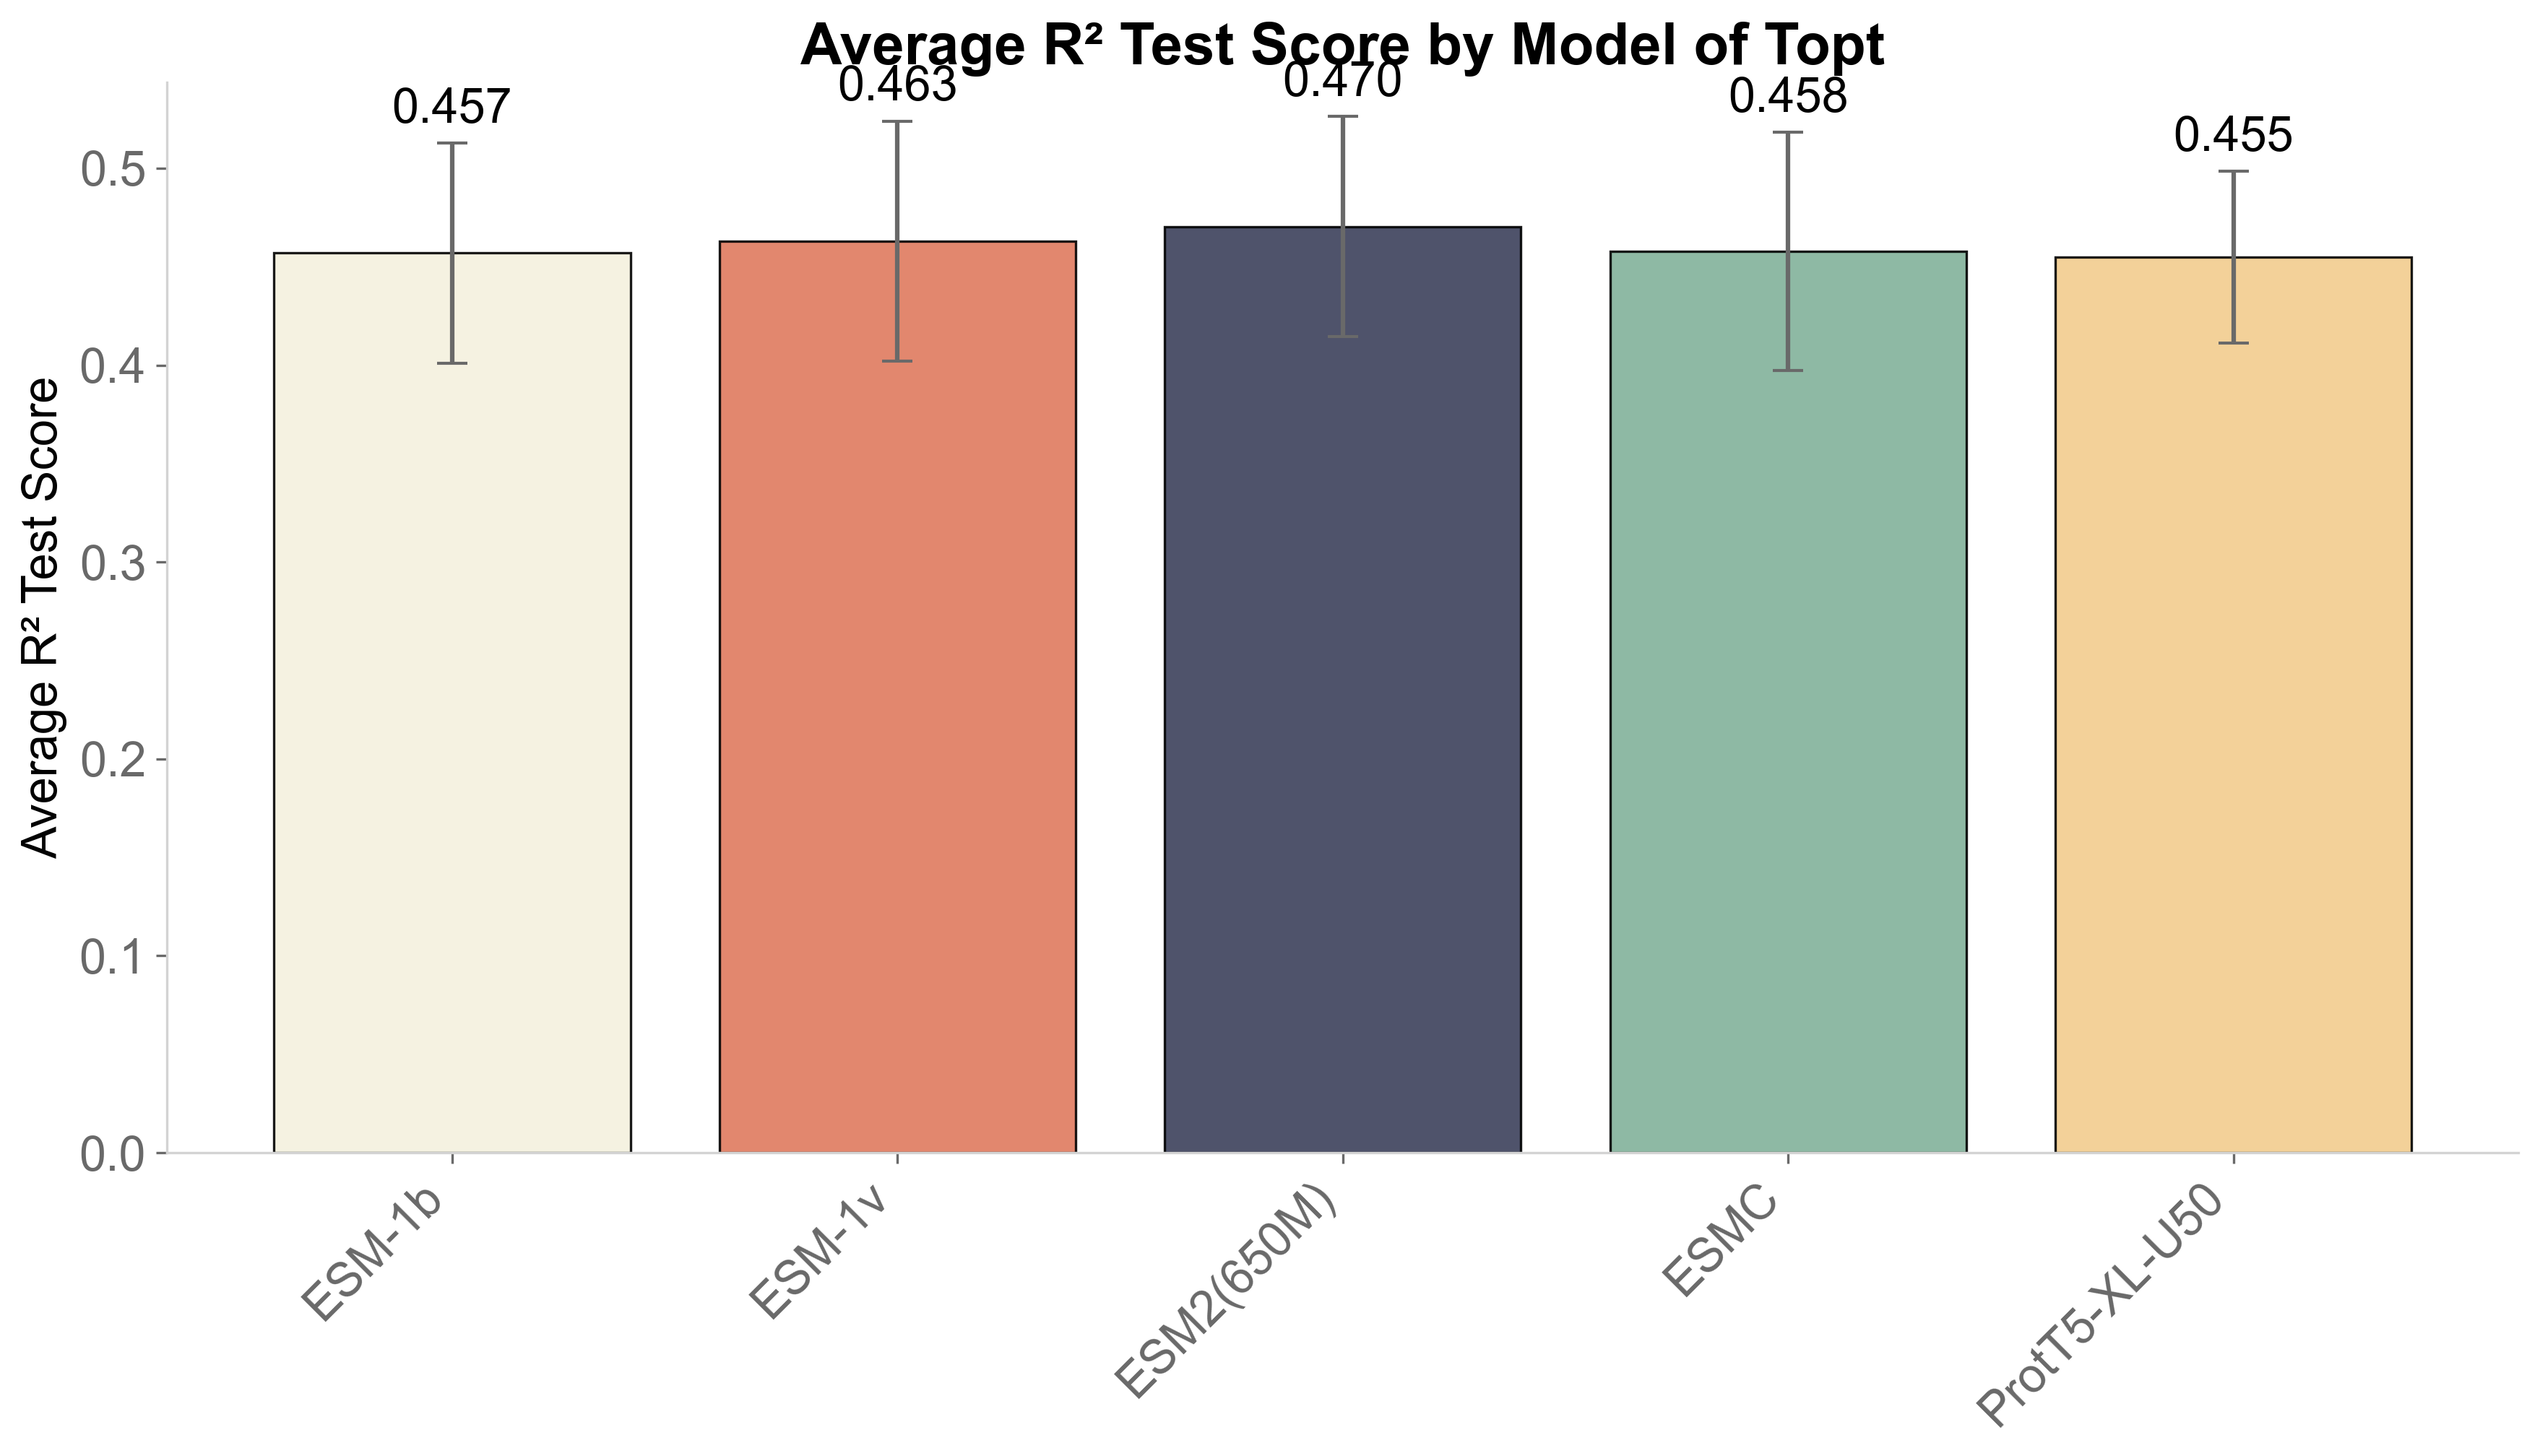

In [5]:
grouped = get_result('tomer')
# 6. 绘制带误差条的柱状图
models = grouped['Model']
display_models = grouped['Display_Model']
# models = ['ESM-1b', 'ESM-1v', 'ESM2(650M)', 'ESMC', 'ProtT5-XL-U50']
means = grouped['avg_r2']
errors = grouped['std_r2']

# --- 4. 优化绘图设置 (rcParams 影响全局样式) ---
# 可以选择使用一套更专业的风格，例如 'seaborn-v0_8-whitegrid' 或 'ggplot'
# plt.style.use('seaborn-v0_8-whitegrid') # 例如，使用seaborn风格
# 如果不想改变全局风格，手动调整参数

# 手动调整一些常用的美化参数
mpl.rcParams['axes.edgecolor'] = 'lightgray' # 坐标轴颜色
mpl.rcParams['axes.linewidth'] = 0.8      # 坐标轴线宽
mpl.rcParams['grid.color'] = 'lightgray'    # 网格线颜色
mpl.rcParams['grid.linestyle'] = '--'       # 网格线样式
mpl.rcParams['grid.alpha'] = 0.7          # 网格线透明度
mpl.rcParams['xtick.color'] = 'dimgray'   # X轴刻度颜色
mpl.rcParams['ytick.color'] = 'dimgray'   # Y轴刻度颜色
mpl.rcParams['text.color'] = 'dimgray'    # 文本颜色 (包括标签和标题)
mpl.rcParams['font.family'] = 'sans-serif' # 使用无衬线字体
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'] # 备选字体
mpl.rcParams['font.size'] = 16

# --- 5. 创建图表 ---
fig, ax = plt.subplots(figsize=(12, 7), dpi=300) # 调整图表大小和DPI

# --- 6. 绘制带误差条的柱状图 (优化) ---
# 使用单个颜色或更协调的颜色方案
bar_color = ['#F4F1DE', '#DF7A5E', '#3C405B', '#82B29A', '#F2CC8E']
error_color = 'dimgray' # 或使用 'black' 或 'gray'

bars = ax.bar(models, means, yerr=errors,
                capsize=5,          # 误差条帽的大小
                color=bar_color,    # 柱子颜色
                edgecolor='black',  # 柱子边框颜色 (可选)
                linewidth=0.8,      # 柱子边框线宽 (可选)
                ecolor=error_color, # 误差条颜色
                alpha=0.9)          # 稍微调高透明度或完全不透明

# --- 7. 设置图表标题和标签 (优化) ---
ax.set_ylabel('Average R² Test Score', color='black') # 更清晰的标签
ax.set_title('Average R² Test Score by Model of Topt', fontweight='bold', color='black') # 更具描述性的标题

# 设置X轴刻度和标签
ax.set_xticks(np.arange(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right') # 调整字体大小和旋转

# --- 8. 移除不必要的图表边框 ---
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# --- 9. 显示网格线 (优化) ---
# ax.yaxis.grid(True, linestyle='--', alpha=0.6) # 使用虚线网格线
# ax.xaxis.grid(False) # 通常柱状图不需要X轴网格

# --- 10. 添加数值标签到柱子上 ---
# 在每个柱子的顶部显示平均R2值
for bar in bars:
    yval = bar.get_height() # 获取柱子的高度 (即平均值)
    # 获取误差条的高度 (从数据中读取errors)
    model_name = bar.get_x() + bar.get_width()/2 # X position of the bar center
    model_index = list(models).index(grouped[grouped['avg_r2'] == yval]['Model'].iloc[0]) # Find the index of the model for this bar
    error_val = errors.iloc[model_index] if pd.notna(errors.iloc[model_index]) else 0

    # Position the text slightly above the top of the bar + error bar
    # Add a small buffer (e.g., 0.02 for R2 values, or a percentage of the plot range)
    buffer = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01 # 1% of y-range as buffer

    # Calculate text position: slightly above the mean + std error
    text_y_pos = yval + error_val + buffer

    # Ensure text is visible if error bar goes below zero or mean is negative
    # A simpler approach is to place it relative to the top of the bar + error bar,
    # but adjust vertical alignment if the mean is negative.
    # Let's place it relative to the top of the error bar + buffer
    # If mean is negative, error bar goes downwards. Position text below mean - error.
    if yval >= 0:
            text_y_pos = yval + error_val + buffer
            va_align = 'bottom' # Vertical alignment below the point
    else:
            text_y_pos = yval - error_val - buffer
            va_align = 'top' # Vertical alignment above the point

    ax.text(bar.get_x() + bar.get_width()/2, text_y_pos,
            f'{yval:.3f}', # 格式化为小数点后3位
            ha='center', va=va_align, # 水平居中，垂直根据值调整
             color='black') # 字体大小和颜色
ax.set_xticklabels(display_models, rotation=45, ha='right') # 调整字体大小和旋转
# --- 11. 调整Y轴范围 (可选，根据数据范围调整) ---
min_r2 = grouped['avg_r2'].min() - grouped['std_r2'].max() * 1.2 # Consider lowest possible point with error
max_r2 = grouped['avg_r2'].max() + grouped['std_r2'].max() * 1.2 # Consider highest possible point with error
ax.set_ylim([min(0, min_r2), max_r2]) # Ensure 0 is included if possible or needed

# --- 12. 自动调整布局并显示图表 ---
plt.tight_layout() # 自动调整子图参数，以紧凑布局
plt.show()

In [1]:
import pandas as pd
import os
from collections import defaultdict
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
r2_dict = defaultdict(list)
rmse_dict = defaultdict(list)
for file in os.listdir('../results/'):
    if file.endswith('.csv'):
        df = pd.read_csv(f'../results/{file}')
        df = df[df['Test'] == 1]
        r2_dict[file] = r2_score(df['topt'], df['Predicted Topt'])
        rmse_dict[file] = root_mean_squared_error(df['topt'], df['Predicted Topt'])

rmse_dict

defaultdict(list,
            {'tomer_esm1v_results_cv3.csv': 14.023101065392122,
             'tomer_esmc_results_cv1.csv': 13.577154201927291,
             'tomer_esmc_results_cv2.csv': 13.521513601045596,
             'tomer_prott5_results_cv0.csv': 13.4493062406924,
             'tomer_esm1b_results_cv1.csv': 13.626097653483615,
             'tomer_prollama_results_cv0.csv': 13.964751100489936,
             'tomer_prollama_results_cv3.csv': 14.60709096875365,
             'tomer_esm1v_results_cv0.csv': 13.456078144955205,
             'tomer_prott5_results_cv3.csv': 14.164406851227767,
             'tomer_prott5_results_cv4.csv': 13.632106987068006,
             'tomer_esmc_results_cv3.csv': 14.197567224006868,
             'tomer_prott5_results_cv1.csv': 13.265333342119044,
             'tomer_prollama_results_cv4.csv': 14.267448443075521,
             'tomer_esm1b_results_cv3.csv': 13.996549162777187,
             'tomer_prollama_results_cv1.csv': 13.894527537372431,
            

In [2]:
r2_dict

defaultdict(list,
            {'tomer_esm1v_results_cv3.csv': 0.4000032080589957,
             'tomer_esmc_results_cv1.csv': 0.4272808408906913,
             'tomer_esmc_results_cv2.csv': 0.49546298099645725,
             'tomer_prott5_results_cv0.csv': 0.4573151351829631,
             'tomer_esm1b_results_cv1.csv': 0.4231442780509276,
             'tomer_prollama_results_cv0.csv': 0.4149212251112411,
             'tomer_prollama_results_cv3.csv': 0.3489890880038171,
             'tomer_esm1v_results_cv0.csv': 0.45676849952878407,
             'tomer_prott5_results_cv3.csv': 0.3878503779684055,
             'tomer_prott5_results_cv4.csv': 0.5092108082241285,
             'tomer_esmc_results_cv3.csv': 0.38498080904728116,
             'tomer_prott5_results_cv1.csv': 0.45328555812116944,
             'tomer_prollama_results_cv4.csv': 0.4623970513487803,
             'tomer_esm1b_results_cv3.csv': 0.40227317303518106,
             'tomer_prollama_results_cv1.csv': 0.4001926567288673,
    

defaultdict(list,
            {'tomer_esm1v_results_etr.csv': 0.4625055668618143,
             'tomer_esm1b_results_etr.csv': 0.462192597219365,
             'tomer_esm2_results_etr.csv': 0.4649703913662143,
             'tomer_prott5_results.csv': 0.4573151351829631,
             'tomer_full_results.csv': 0.43143000208466553,
             'tomer_esm2_results.csv': 0.4404894815215866,
             'tomer_esmc_results.csv': 0.4417523053526269,
             'tomer_esm1v_results.csv': 0.45676849952878407,
             'tomer_prott5_results_etr.csv': 0.4770502062940274,
             'tomer_esm1b_results.csv': 0.43145292912024447,
             'tomer_esmc_results_etr.csv': 0.4610952811818495})
做了scalar的结果


不做scalar:
defaultdict(list,
            {'tomer_esm1v_results_etr.csv': 0.46233906704253147,
             'tomer_esm1b_results_etr.csv': 0.4623118076177506,
             'tomer_esm2_results_etr.csv': 0.4648146046282916,
             'tomer_prott5_results_etr.csv': 0.4773700876959648,
             'tomer_esmc_results_etr.csv': 0.4606008744243163})
             不如上面

In [3]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

data = r2_dict

# 按模型分类
model_performance = defaultdict(list)
for filename, rmse in data.items():
    # 提取模型名称 (如 'esm2' from 'tomer_esm2_results_cv1.csv')
    model_name = filename.split('_')[1]
    model_performance[model_name].append(rmse)

In [ ]:
model_stats = {}
for model, values in model_performance.items():
    model_stats[model] = {
        'mean': np.mean(values),
        'std': np.std(values, ddof=1),  # 样本标准差
        'sem': np.std(values, ddof=1)/np.sqrt(len(values)),  # 标准误差
        'n': len(values)
    }

In [10]:
target_models = ['esm2', 'esm1b', 'esmc', 'esm1v', 'prollama', 'prott5']
x_labels = ['ESM2(650M)', 'ESM-1b', 'ESMC', 'ESM-1v', 'ProLLaMA', 'ProtT5-XL-U50']
means = [model_stats[model]['mean'] for model in target_models]
errors = [model_stats[model]['sem'] for model in target_models]  # 或用std

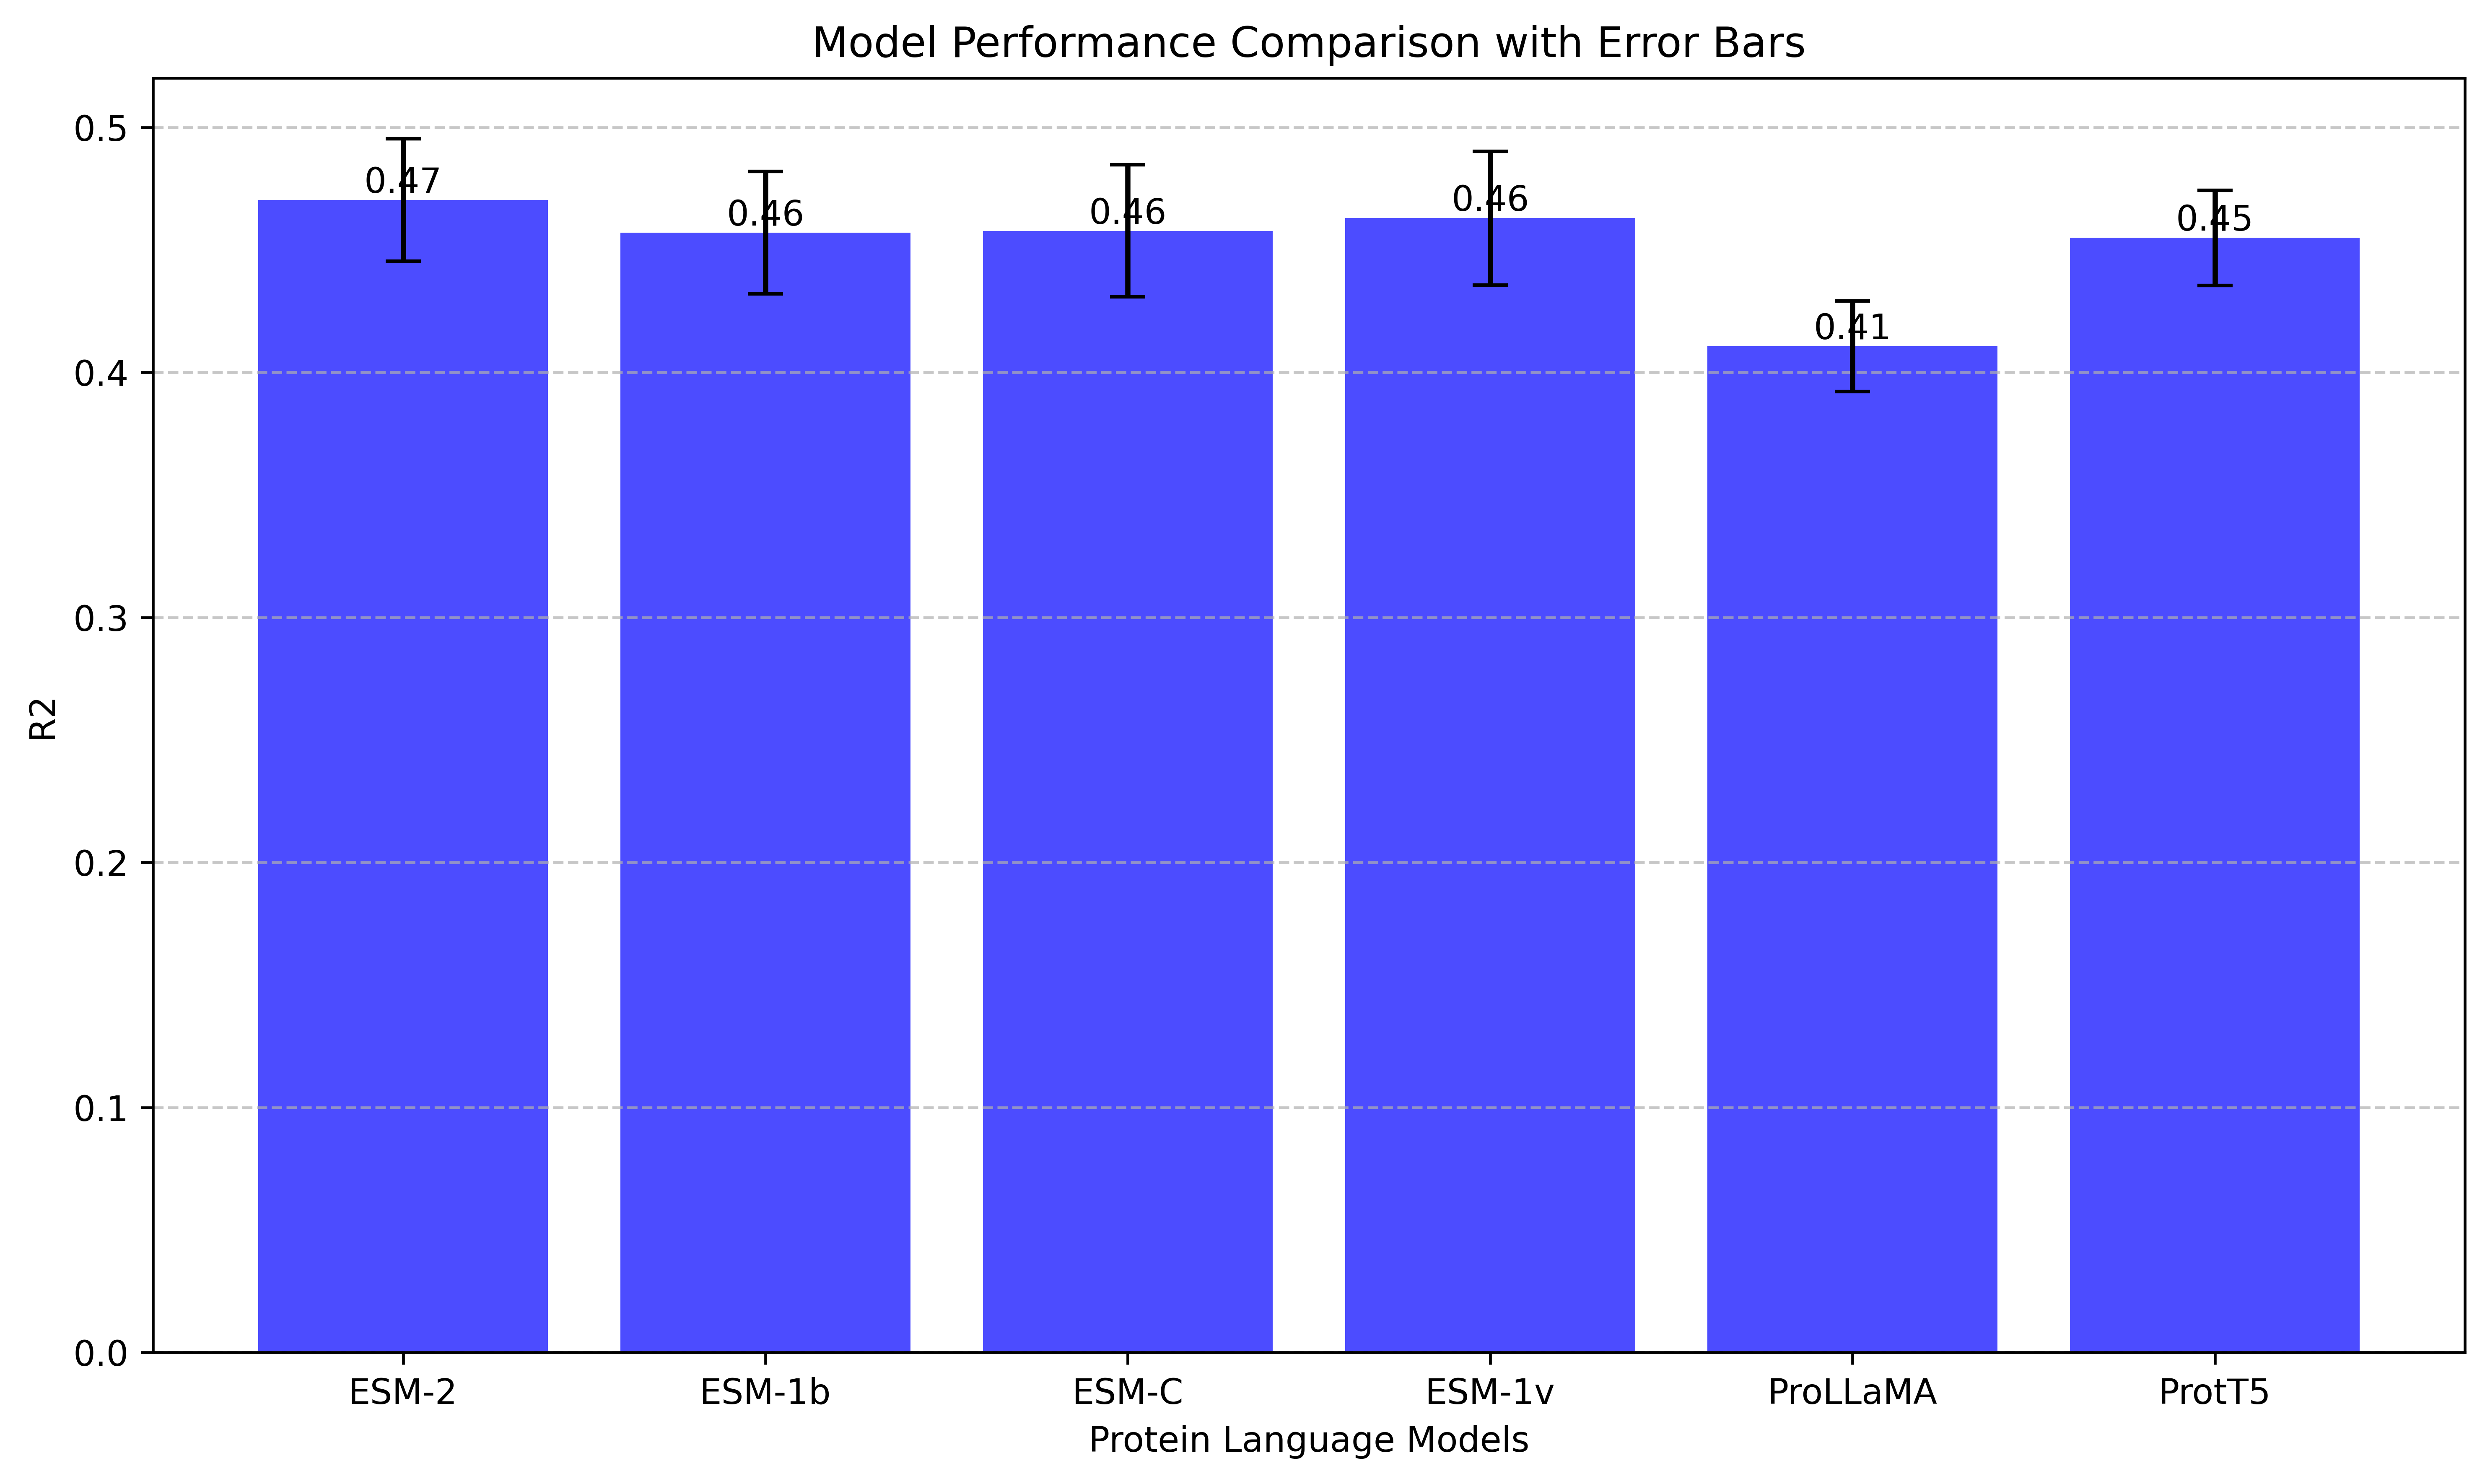

In [11]:
plt.figure(figsize=(10, 6), dpi=600)
bars = plt.bar(x_labels, means, yerr=errors, 
               capsize=5, alpha=0.7, color='blue')

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom')

plt.xlabel('Protein Language Models')
plt.ylabel('R2')
plt.title('Model Performance Comparison with Error Bars')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=300)
plt.show()